# Micrograd Tensor Addition

## 1. Imports

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Building out Tensor Class

In [2]:
class Tensor:
  def __init__(self, data, _children=(), _op=''):
    self.data = np.array(data, dtype=np.float32)
    self.grad = np.zeros_like(self.data)
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op

  def __repr__(self):
    return f"Tensor({self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data + other.data, (self, other), "+")
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data * other.data, (self, other), "*")
    return out

  def __matmul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data @ other.data, (self, other), "@")
    return out

  def __neg__(self):
    return Tensor(self.data * -1, (self,), "neg")

  def __sub__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data - other.data, (self, other), "-")
    return out

  def __truediv__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data / other.data, (self, other), "/")
    return out

  def transpose(self):
    out = Tensor(self.data.T, (self,), "T")
    return out

In [3]:
a = Tensor([1, 2, 3])

In [4]:
b = Tensor([1, 2, 3])
a + b

Tensor([2. 4. 6.])

In [5]:
c = Tensor([1])
a + c

Tensor([2. 3. 4.])

In [6]:
a = Tensor([1, 2, 3])
b = Tensor([1, 2, 3])
c = Tensor([1, 2, 3])

d = (a + b) * c
d

Tensor([ 2.  8. 18.])

In [32]:
from graphviz import Digraph
import numpy as np

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges


def _format_tensor_data(arr):
    """Formats 0D/1D/ND NumPy arrays cleanly for Graphviz record labels."""
    if arr is None:
        return "None"

    # 0D scalars or single-element arrays
    if arr.ndim == 0 or arr.size == 1:
        return f"{float(arr.squeeze()):.4f}"

    # Multi-element arrays: display shape and compact array values
    shape_str = f"shape {arr.shape}"
    arr_str = np.array2string(arr, precision=2, suppress_small=True, separator=', ')
    clean_arr = arr_str.replace('\n', ' ')  # avoid breaking Graphviz record lines
    return f"{shape_str} \\n {clean_arr}"


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))

        # Include label if available on the instance
        label_prefix = f"{n.label} | " if hasattr(n, 'label') and n.label else ""

        data_str = _format_tensor_data(n.data)
        grad_str = _format_tensor_data(n.grad)

        # Construct Graphviz record label
        node_label = f"{{{label_prefix}data: {data_str} | grad: {grad_str}}}"
        dot.node(name=uid, label=node_label, shape='record')

        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [33]:
a = Tensor([1, 2, 3]); a.label = 'a'
b = Tensor([1, 2, 3]); b.label = 'b'
c = Tensor([1, 2, 3]); c.label = 'c'

d = (a + b) @ c; d.label = 'd'
d

Tensor(28.0)

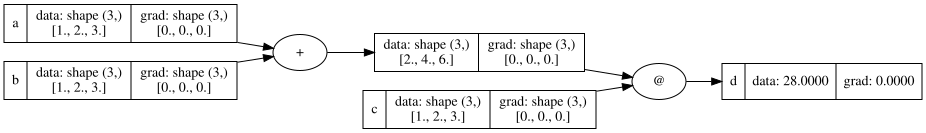

In [34]:
draw_dot(d)

In [35]:
d._prev

{Tensor([1. 2. 3.]), Tensor([2. 4. 6.])}

In [36]:
d._op

'@'

In [37]:
a = Tensor([[1], [2]]); a.label = 'a'
b = Tensor([[1, 2, 3]]); b.label = 'b'
c = Tensor([[1, 0, 0], [0, 1, 0]]); c.label = 'c'
d = a @ b; d.label = 'd'
e = c + d; e.label = 'e'
f = Tensor([[1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1]]); f.label = 'f'
L = e @ f; L.label = 'L'
L

Tensor([[ 7.  7.  7.  7.]
 [13. 13. 13. 13.]])

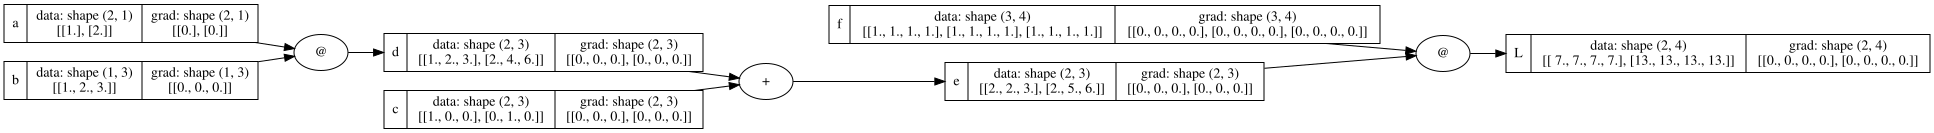

In [38]:
draw_dot(L)

## 3. Manual Backpropagation

In [39]:
L.grad = Tensor(np.ones_like(L.data))
L.grad

Tensor([[1. 1. 1. 1.]
 [1. 1. 1. 1.]])

In [40]:
# dL/de = ?
# L.grad shape = (2,4), e.grad shape = (2,3) f.grad shape = (3,4)
# dL/de = L.grad @ f.transpose()

e.grad = L.grad @ f.transpose()
e.grad

Tensor([[4. 4. 4.]
 [4. 4. 4.]])

In [41]:
# dL/df = ?
# L.grad shape = (2,4), e.grad shape = (2,3) f.grad shape = (3,4)
# dL/df = e.transpose() @ L.grad

f.grad = e.transpose() @ L.grad
f.grad

Tensor([[4. 4. 4. 4.]
 [7. 7. 7. 7.]
 [9. 9. 9. 9.]])

In [42]:
# dL/dc = ?
# same as with numbers -> c.grad = e.grad * 1.0

c.grad = e.grad * 1.0
c.grad

Tensor([[4. 4. 4.]
 [4. 4. 4.]])

In [43]:
d.grad = e.grad * 1.0
d.grad

Tensor([[4. 4. 4.]
 [4. 4. 4.]])

In [44]:
# dL/da = ?
# a.grad = d.grad @ b.transpose()

a.grad = d.grad @ b.transpose()
a.grad

Tensor([[24.]
 [24.]])

In [45]:
# dL/db = ?
# b.grad = a.transpose() @ d.grad

b.grad = a.transpose() @ d.grad
b.grad

Tensor([[12. 12. 12.]])

## 4. Automating Backpropagation

In [53]:
class Tensor:
  def __init__(self, data, _children=(), _op=''):
    self.data = np.array(data, dtype=np.float32)
    self.grad = np.zeros_like(self.data)
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op

  def __repr__(self):
    return f"Tensor({self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data + other.data, (self, other), "+")

    def _backward():
      self.grad += out.grad * 1.0
      other.grad += out.grad * 1.0
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad += out.grad * other.data
      other.grad += out.grad * self.data

    out._backward = _backward
    return out

  def __matmul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data @ other.data, (self, other), "@")

    def _backward():
      self.grad += out.grad @ other.data.T
      other.grad += self.data.T @ out.grad
    out._backward = _backward
    return out

  def __neg__(self):
    return Tensor(self.data * -1, (self,), "neg")

  def __sub__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data - other.data, (self, other), "-")
    return out

  def __truediv__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data / other.data, (self, other), "/")
    return out

  def transpose(self):
    out = Tensor(self.data.T, (self,), "T")
    return out

In [54]:
a = Tensor([[1], [2]])
b = Tensor([[1, 2, 3]])
c = Tensor([[1, 0, 0], [0, 1, 0]])
d = a @ b
e = c + d
f = Tensor([[1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1]])
L = e @ f
L

Tensor([[ 7.  7.  7.  7.]
 [13. 13. 13. 13.]])

In [57]:
L.grad = np.ones_like(L.data)
L._backward()

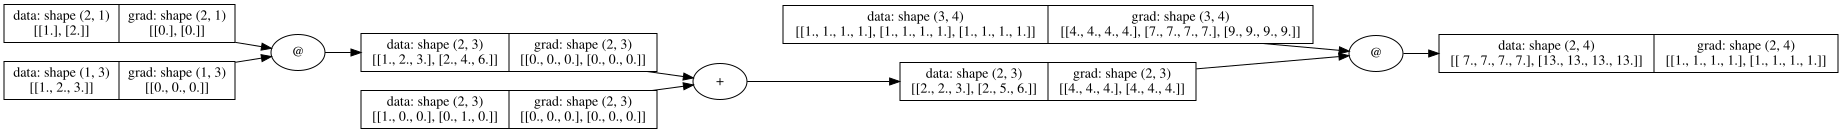

In [58]:
draw_dot(L)

In [60]:
# Topological Sort
#
# We are using topological sort L->R as we want to get graph elements from left to right inside a list
# and each element only comes after its inputs
# That way we can automate backpropagation
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)

build_topo(L)
topo

[Tensor([[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]),
 Tensor([[1. 0. 0.]
  [0. 1. 0.]]),
 Tensor([[1.]
  [2.]]),
 Tensor([[1. 2. 3.]]),
 Tensor([[1. 2. 3.]
  [2. 4. 6.]]),
 Tensor([[2. 2. 3.]
  [2. 5. 6.]]),
 Tensor([[ 7.  7.  7.  7.]
  [13. 13. 13. 13.]])]

In [61]:
class Tensor:
  def __init__(self, data, _children=(), _op=''):
    self.data = np.array(data, dtype=np.float32)
    self.grad = np.zeros_like(self.data)
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op

  def __repr__(self):
    return f"Tensor({self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data + other.data, (self, other), "+")

    def _backward():
      self.grad += out.grad * 1.0
      other.grad += out.grad * 1.0
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad += out.grad * other.data
      other.grad += out.grad * self.data

    out._backward = _backward
    return out

  def __matmul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data @ other.data, (self, other), "@")

    def _backward():
      self.grad += out.grad @ other.data.T
      other.grad += self.data.T @ out.grad
    out._backward = _backward
    return out

  def __neg__(self):
    return Tensor(self.data * -1, (self,), "neg")

  def __sub__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data - other.data, (self, other), "-")
    return out

  def __truediv__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data / other.data, (self, other), "/")
    return out

  def transpose(self):
    out = Tensor(self.data.T, (self,), "T")
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    self.grad = np.ones_like(self.data)
    for node in reversed(topo):
      node._backward()

In [62]:
a = Tensor([[1], [2]])
b = Tensor([[1, 2, 3]])
c = Tensor([[1, 0, 0], [0, 1, 0]])
d = a @ b
e = c + d
f = Tensor([[1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1]])
L = e @ f
L

Tensor([[ 7.  7.  7.  7.]
 [13. 13. 13. 13.]])

In [63]:
L.backward()

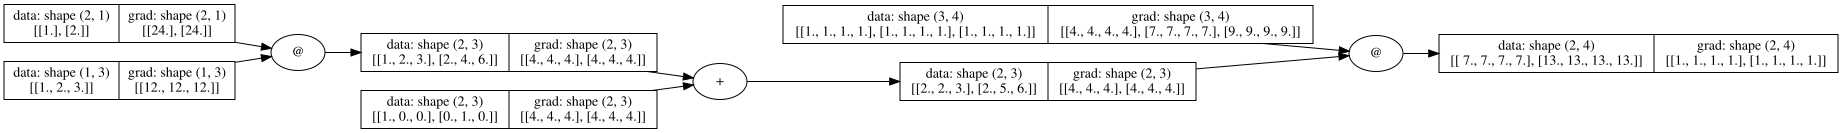

In [64]:
draw_dot(L)

## 5. Backpropagation on Tensors in PyTorch

In [67]:
import torch

a = torch.tensor([[1.0], [2.0]], requires_grad=True)
b = torch.tensor([[1.0, 2.0, 3.0]], requires_grad=True)
c = torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]], requires_grad=True)
d = a @ b
e = c + d
f = torch.tensor([[1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0]], requires_grad=True)
L = e @ f

L.backward(torch.ones_like(L))

print('---')
print("a.grad:\n", a.grad)
print("b.grad:\n", b.grad)
print("c.grad:\n", c.grad)
print("f.grad:\n", f.grad)

---
a.grad:
 tensor([[24.],
        [24.]])
b.grad:
 tensor([[12., 12., 12.]])
c.grad:
 tensor([[4., 4., 4.],
        [4., 4., 4.]])
f.grad:
 tensor([[4., 4., 4., 4.],
        [7., 7., 7., 7.],
        [9., 9., 9., 9.]])
